In [5]:
# import hierarchal clustering libries
import scipy.cluster.hierarchy as sch   # plotting the dendogram
from sklearn.cluster import AgglomerativeClustering  #creating the clusters
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn

In [11]:
df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Universities.csv')
df.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


In [10]:
# Normalization function custom written we can also use the sklearn prdef function
def norm_func(i):
    x = (i-i.min())/(i.max()-i.min())
    return (x)

In [14]:
# Normalize the dataset (consider the numerical part of the data)
df_norm = norm_func(df.iloc[:,1:])

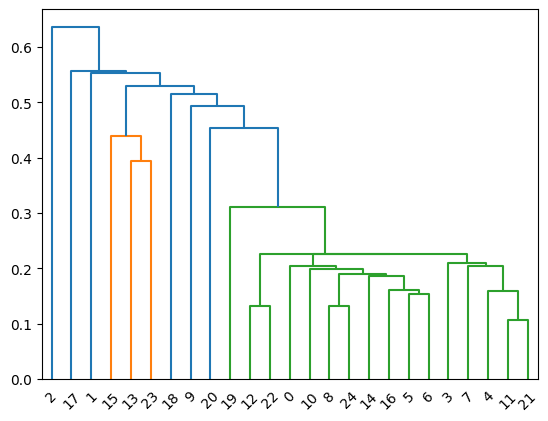

In [15]:
# creatinf the dendogram
dendrogram = sch.dendrogram(sch.linkage(df_norm,method='single'))

In [19]:
# creating the cluster

hc = AgglomerativeClustering( n_clusters=4, metric = 'euclidean',linkage = 'single')

In [21]:
# save cluster for chart
y_hc = hc.fit_predict(df_norm)
Clusters = pd.DataFrame(y_hc , columns=['Clusters'])

In [25]:
Clusters


,Clusters
0,0
1,3
2,1
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [26]:
df_norm['h_clusterid']= Clusters

In [28]:
df_norm.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,h_clusterid
0,0.743902,0.847222,0.105263,0.368421,0.255144,0.900000,0
1,1.000000,1.000000,0.144737,0.000000,1.000000,0.466667,3
2,0.621951,0.472222,0.592105,0.157895,0.297461,0.166667,1
3,0.743902,0.666667,0.131579,0.315789,0.415629,0.700000,0
4,0.670732,0.763889,0.250000,0.368421,0.239835,0.766667,0


In [30]:
df['h_clusterid']= Clusters
df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,h_clusterid
0,Brown,1310,89,22,13,22704,94,0
1,CalTech,1415,100,25,6,63575,81,3
2,CMU,1260,62,59,9,25026,72,1
3,Columbia,1310,76,24,12,31510,88,0
4,Cornell,1280,83,33,13,21864,90,0
5,Dartmouth,1340,89,23,10,32162,95,0
6,Duke,1315,90,30,12,31585,95,0
7,Georgetown,1255,74,24,12,20126,92,0
8,Harvard,1400,91,14,11,39525,97,0
9,JohnsHopkins,1305,75,44,7,58691,87,0
